# About

- Implement a `torch.utils.data.DataLoader`.
- Implement a `pytorch_lightning.LightningDataModule`
- Build a **3D** segmentation model from [medicai](https://github.com/innat/medic-ai) using the **PyTorch** backend
- Implement a `pytorch_lightning.LightningModule`

---

**Note**: This is just a fun experiment. We’ll be using **Keras 3**–based 3D segmentation models (running on the **PyTorch** backend), while the data loading and training loop are handled entirely through **PyTorch Lightning**.

**Caveat**: The loss and metrics (Dice-CE loss and Dice metric) come from **Keras 3** via `medicai`, because PyTorch does not provide these specialized components out of the box. They could be replaced by pure-PyTorch implementations at any time. Now, in Keras, the conventions differ slightly:
- Loss functions follow `fn(y_true, y_pred)` - as opposed to PyTorch’s `fn(y_pred, y_true)`
- Metrics follow: 
    - `metric.update_state(y_true, y_pred)` per batch
    - `metric.result()` when retrieving current value
    - `metric.reset_state()` at the end of each epoch

If you switch to native **PyTorch** loss functions and metrics, you can ignore these differences.

In [1]:
!pip uninstall -y protobuf -q
!pip install protobuf==5.26.1 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 6.6 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-cloud-translate 3.12.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.19.5, but you have protobuf 5.26.1 which is incompatible.
a2a-sdk 0.3.10 requires protobuf>=5.29.5, but you have protobuf 5.26.1 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 46.0.3 which is incompatible.
pydrive2 1.21.3 requires pyOpenSSL<=24.2.1,>=19.1.0, but you have pyopenssl 25.3

In [2]:
!pip install git+https://github.com/innat/medic-ai.git -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
import os, warnings

os.environ["KERAS_BACKEND"] = "torch"
os.environ["XLA_FLAGS"] = "--xla_gpu_force_compilation_parallelism=1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3" 
warnings.filterwarnings('ignore')

In [4]:
import glob
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [5]:
root_dir = "/kaggle/input/vesuvius-npy"
images_dir = f"{root_dir}/train_images"
labels_dir = f"{root_dir}/train_labels"
all_image_files = sorted(glob.glob(os.path.join(images_dir, "*.npy")))
all_label_files = sorted(glob.glob(os.path.join(labels_dir, "*.npy")))

train_imgs, val_imgs, train_lbls, val_lbls = train_test_split(
    all_image_files,
    all_label_files,
    test_size=5,
    random_state=42,
    shuffle=True,
)

print("Train images:", len(train_imgs), len(train_lbls))
print("Val images:  ", len(val_imgs), len(val_lbls))

Train images: 801 801
Val images:   5 5


In [8]:
import keras
from keras import ops

import torch
import pytorch_lightning as pl

from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor
from pytorch_lightning.callbacks import Callback

import medicai
from medicai.transforms import (
    Compose,
    ScaleIntensityRange,
    Resize,
    RandShiftIntensity,
    RandRotate90,
    RandFlip,
    RandSpatialCrop
)
from medicai.models import SegFormer
from medicai.losses import BinaryDiceCELoss
from medicai.metrics import BinaryDiceMetric
from medicai.utils.inference import SlidingWindowInference

In [9]:
keras.version(), keras.config.backend(), pl.__version__, medicai.version()

('3.8.0', 'torch', '2.5.5', '0.0.3')

# Data Loader

In [10]:
def train_transformation(image, label):
    data = {"image": image, "label": label}
    pipeline = Compose([
        ScaleIntensityRange(
            keys=["image"],
            a_min = 0,
            a_max = 255,
            clip = True,
        ),
        RandSpatialCrop(
            keys=["image", "label"],
            roi_size=(128,128,128),
        ),
        RandFlip(keys=["image", "label"], spatial_axis=[0], prob=0.5),
        RandFlip(keys=["image", "label"], spatial_axis=[1], prob=0.5),
        RandFlip(keys=["image", "label"], spatial_axis=[2], prob=0.5),
        RandRotate90(
            keys=["image", "label"], 
            prob=0.4, 
            max_k=3, 
            spatial_axes=(0, 1)
        ),
        RandShiftIntensity(keys=["image"], offsets=0.10, prob=0.5)
    ])
    result = pipeline(data)
    
    return (
        ops.convert_to_numpy(result["image"]), 
        ops.convert_to_numpy(result["label"])
    )


def val_transformation(image, label):
    data = {"image": image, "label": label}
    pipeline = Compose([
        ScaleIntensityRange(
            keys=["image"],
            a_min = 0,
            a_max = 255,
            clip = True,
        ),
    ])
    result = pipeline(data)
    return (
        ops.convert_to_numpy(result["image"]), 
        ops.convert_to_numpy(result["label"])
    )

In [11]:
class VesuviusDataset(torch.utils.data.Dataset):
    def __init__(self, image_paths, label_paths, training=True):
        self.images = image_paths
        self.labels = label_paths
        self.training = training

    def __len__(self):
        return len(self.images)

    def load_npy(self, path):
        array = np.load(path)   
        array = array[..., None]
        array = array.astype(np.float32)
        return array

    def __getitem__(self, idx):
        # load volumes
        image = self.load_npy(self.images[idx])    
        label = self.load_npy(self.labels[idx])
        label = (label == 1)

        # apply transforms
        if self.training:
            image, label = train_transformation(image, label)
        else:
            image, label = val_transformation(image, label)

        # convert to tensors
        image = torch.from_numpy(image).float()
        label = torch.from_numpy(label).float()
        return image, label

In [12]:
check_out_ds = VesuviusDataset(val_imgs, val_lbls, training=False)
check_out_loader = torch.utils.data.DataLoader(
    check_out_ds,
    batch_size=1,
    shuffle=False,
    num_workers=4,
)

In [13]:
x, y = next(iter(check_out_loader))
x.shape, y.shape

(torch.Size([1, 320, 320, 320, 1]), torch.Size([1, 320, 320, 320, 1]))

In [14]:
def plot_sample(x, y, sample_idx=0, max_slices=16):
    img = np.squeeze(x[sample_idx])  # (D, H, W)
    mask = np.squeeze(y[sample_idx])  # (D, H, W)
    D = img.shape[0]

    # Decide which slices to plot
    step = max(1, D // max_slices)
    slices = range(0, D, step)

    n_slices = len(slices)
    fig, axes = plt.subplots(2, n_slices, figsize=(3*n_slices, 6))

    for i, s in enumerate(slices):
        axes[0, i].imshow(img[s], cmap='gray')
        axes[0, i].set_title(f"Slice {s}")
        axes[0, i].axis('off')

        axes[1, i].imshow(mask[s], cmap='gray')
        axes[1, i].set_title(f"Mask {s}")
        axes[1, i].axis('off')

    plt.suptitle(f"Sample {sample_idx}")
    plt.tight_layout()
    plt.show()

In [15]:
def plot_planes(image, mask, alpha=0.4):
    image = np.squeeze(image)
    mask = np.squeeze(mask)
    # Central slices
    d, h, w = image.shape
    axial_img    = image[d // 2]
    coronal_img  = image[:, h // 2, :]
    sagittal_img = image[:, :, w // 2]

    axial_msk    = mask[d // 2]
    coronal_msk  = mask[:, h // 2, :]
    sagittal_msk = mask[:, :, w // 2]

    slices_img = [axial_img, coronal_img, sagittal_img]
    slices_msk = [axial_msk, coronal_msk, sagittal_msk]
    
    titles = ["Axial (XY plane)", "Coronal (XZ plane)", "Sagittal (YZ plane)"]
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for i, ax in enumerate(axes):
        ax.imshow(slices_img[i], cmap="gray")

        # overlay jet only where mask > 0
        m = slices_msk[i]
        if m.max() > 0:
            ax.imshow(m, cmap="jet", alpha=alpha)

        ax.set_title(titles[i])
        ax.axis("off")

    plt.tight_layout()
    plt.show()

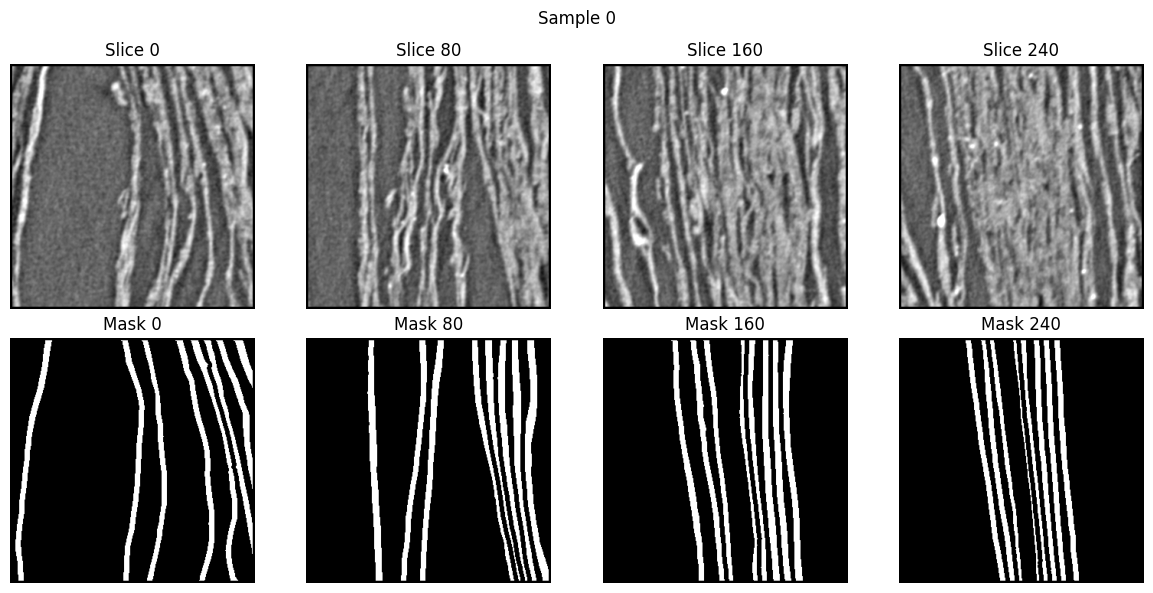

In [16]:
plot_sample(
    x, y, sample_idx=0, max_slices=4
)

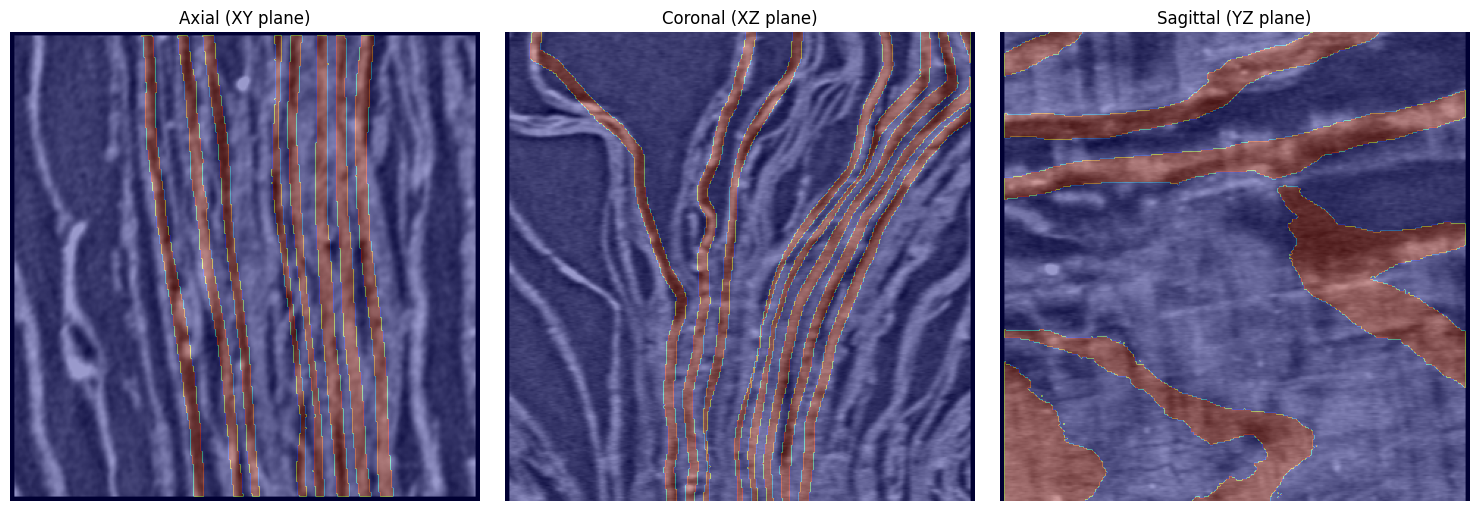

In [17]:
plot_planes(
    x[0], # picking one sample
    y[0]  # picking one sample
)

# Lightning DataModule

In [18]:
class VesuviusDataModule(pl.LightningDataModule):
    def __init__(
        self,
        train_imgs, 
        train_lbls, 
        val_imgs, 
        val_lbls,
        train_batch_size=2,
        val_batch_size=1,
        num_workers=4,
    ):
        super().__init__()
        self.train_imgs = train_imgs
        self.train_lbls = train_lbls
        self.val_imgs = val_imgs
        self.val_lbls = val_lbls
        self.train_batch_size = train_batch_size
        self.val_batch_size = val_batch_size
        self.num_workers = num_workers

    def setup(self, stage=None):
        self.train_ds = VesuviusDataset(
            self.train_imgs, self.train_lbls, training=True
        )
        self.val_ds = VesuviusDataset(
            self.val_imgs, self.val_lbls, training=False
        )

    def train_dataloader(self):
        return  torch.utils.data.DataLoader(
            self.train_ds, 
            batch_size=self.train_batch_size, 
            shuffle=True,
            num_workers=self.num_workers, 
            pin_memory=True
        )

    def val_dataloader(self):
        return  torch.utils.data.DataLoader(
            self.val_ds, 
            batch_size=self.val_batch_size, 
            shuffle=False,
            num_workers=self.num_workers, 
            pin_memory=True
        )

# Model

In [19]:
num_classes=1
model = SegFormer(
    input_shape=(128,128,128,1),
    encoder_name='mit_b0',
    classifier_activation='sigmoid',
    num_classes=num_classes,
)
model.compile(jit_compile=False)
sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6

4.491809

# Lightning Module

In [20]:
class VesuviusModel(pl.LightningModule):
    def __init__(
        self,
        model,
        learning_rate=1e-4,
        sw_batch_size=4,
        sw_overlap=0.5
    ):
        super().__init__()
        self.model = model
        self.num_classes = num_classes
        self.learning_rate = learning_rate
        self.sw_batch_size = sw_batch_size
        self.sw_overlap = sw_overlap
        
        # loss / metrics function
        self.criterion = BinaryDiceCELoss(
            from_logits=False, 
            num_classes=num_classes,
            dice_weight=1.0,
            ce_weight=1.0,
        )
        self.train_dice_score = BinaryDiceMetric(
            from_logits=False,
            ignore_empty=True,
            num_classes=num_classes,
            name='dice',
        )
        self.val_dice_score = BinaryDiceMetric(
            from_logits=False,
            ignore_empty=True,
            num_classes=num_classes,
            name='val_dice',
        )
        
        # sliding window inferer for validation
        self.sliding_window_inferer = SlidingWindowInference(
            self.model,
            num_classes=self.num_classes,
            roi_size=(128,128,128),
            sw_batch_size=self.sw_batch_size,
            overlap=self.sw_overlap,
        )
        self.save_hyperparameters(ignore=['model'])

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, masks = batch
        
        # forward pass
        prob = self.forward(images)
        
        # calculate loss
        loss = self.criterion(masks, prob)
        
        # calculate metrics
        self.train_dice_score.update_state(masks, prob)
 
        # log metrics
        current_dice_score = self.train_dice_score.result()
        self.log(
            'train_loss', 
            loss, 
            on_step=True, 
            on_epoch=True, 
            prog_bar=True
        )
        self.log(
            'train_dice', 
            current_dice_score, 
            on_step=True, 
            on_epoch=True, 
            prog_bar=True
        )
        return loss

    def validation_step(self, batch, batch_idx):
        image, mask = batch
        image = ops.convert_to_numpy(image)
        prob = self.sliding_window_inferer(
            image
        )
        self.val_dice_score.update_state(mask, prob)
        
        # calculate loss / metrics
        loss = self.criterion(mask, prob)

        # log loss
        current_dice_score = self.val_dice_score.result()
        self.log(
            'val_loss', loss, on_step=False, on_epoch=True, prog_bar=True
        )
        self.log(
            'val_dice', 
            current_dice_score, 
            on_step=False, 
            on_epoch=True, 
            prog_bar=True
        )
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(), 
            lr=self.learning_rate,
            weight_decay=1e-5
        )

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='max',
            factor=0.5,
            patience=2,
            verbose=True
        )
        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'monitor': 'val_dice',
                'frequency': 1
            }
        }

    def on_train_epoch_end(self):
        # reset metrics at the end of each epoch
        self.train_dice_score.reset_state()

    def on_validation_epoch_end(self):
        # reset metrics at the end of each epoch
        self.val_dice_score.reset_state()

**Custom Print Callback**

In [21]:
class MetricLoggerCallback(Callback):
    def __init__(self, print_every_n_steps=20):
        super().__init__()
        self.print_every_n_steps = print_every_n_steps

    def on_train_batch_end(
        self, trainer, pl_module, outputs, batch, batch_idx
    ):
        global_step = trainer.global_step
        if global_step > 0 and (global_step % self.print_every_n_steps == 0):
            log_metrics = trainer.callback_metrics 
            loss = log_metrics.get('train_loss_step')
            dice = log_metrics.get('train_dice_step')
            print(
                f"[step {global_step}] batch log | "
                f"loss: {loss:.4f}, dice: {dice:.4f}"
            )

    def on_train_epoch_end(self, trainer, pl_module):
        log_metrics = trainer.callback_metrics 
        loss = log_metrics.get('train_loss_epoch')
        dice = log_metrics.get('train_dice_epoch')
        print(
            f"train loss: {loss:.4f}, train dice: {dice:.4f}"
        )
        print("-" * 50)

    def on_validation_epoch_end(self, trainer, pl_module):
        val_loss_key = 'val_loss' 
        val_dice_key = 'val_dice'
        val_loss = (
            trainer.callback_metrics.get(val_loss_key) or 
            trainer.callback_metrics.get(f'{val_loss_key}_epoch')
        )
        val_dice = (
            trainer.callback_metrics.get(val_dice_key) or 
            trainer.callback_metrics.get(f'{val_dice_key}_epoch')
        )
        print(
            f"epoch {trainer.current_epoch + 1:02d} completed: "
            f"val loss: {val_loss:.4f}, val dice: {val_dice:.4f}"
        )

In [22]:
callbacks = [
    MetricLoggerCallback(),
    ModelCheckpoint(
        monitor='val_dice',
        mode='max',
        save_top_k=2,
        save_last=True,
        filename='best-{epoch:02d}-{val_dice:.3f}'
    ),
    LearningRateMonitor(logging_interval='epoch')
]

In [23]:
# create data module
data_module = VesuviusDataModule(
    train_imgs=train_imgs,
    train_lbls=train_lbls,
    val_imgs=val_imgs,
    val_lbls=val_lbls,
    train_batch_size=6,
    val_batch_size=1,
    num_workers=4,
)

# create the Lightning model
lightning_model = VesuviusModel(
    model=model,
    learning_rate=1e-4,
    sw_batch_size=4,
    sw_overlap=0.5
)

In [24]:
trainer = pl.Trainer(
    max_epochs=10,
    callbacks=callbacks,
    accelerator='auto',
    devices='auto',
    log_every_n_steps=1,
    check_val_every_n_epoch=1,
    enable_progress_bar=False,
    num_sanity_val_steps=0
)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [25]:
trainer.fit(lightning_model, datamodule=data_module)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name  | Type      | Params | Mode 
--------------------------------------------
0 | model | SegFormer | 4.5 M  | train
--------------------------------------------
4.5 M     Trainable params
8.7 K     Non-trainable params
4.5 M     Total params
18.002    Total estimated model params size (MB)
4         Modules in train mode
0         Modules in eval mode


[step 20] batch log | loss: 1.3088, dice: 0.2013
[step 40] batch log | loss: 1.3788, dice: 0.2034
[step 60] batch log | loss: 1.3010, dice: 0.1971
[step 80] batch log | loss: 1.3093, dice: 0.1958
[step 100] batch log | loss: 1.3310, dice: 0.1960
[step 120] batch log | loss: 1.2570, dice: 0.1967


Total patch 64: 100%|██████████| 16/16 [00:06<00:00,  2.35it/s]


epoch 01 completed: val loss: 1.2562, val dice: 0.1599
train loss: 1.3185, train dice: 0.1997
--------------------------------------------------
[step 140] batch log | loss: 1.2974, dice: 0.2057
[step 160] batch log | loss: 1.2549, dice: 0.2082
[step 180] batch log | loss: 1.3016, dice: 0.1938
[step 200] batch log | loss: 1.2874, dice: 0.1896
[step 220] batch log | loss: 1.2505, dice: 0.1880
[step 240] batch log | loss: 1.2900, dice: 0.1862
[step 260] batch log | loss: 1.2559, dice: 0.1875


Total patch 64: 100%|██████████| 16/16 [00:06<00:00,  2.37it/s]


...

Total patch 64: 100%|██████████| 16/16 [00:06<00:00,  2.38it/s]


epoch 09 completed: val loss: 1.2032, val dice: 0.2390
train loss: 1.2134, train dice: 0.2430
--------------------------------------------------
[step 1220] batch log | loss: 1.1930, dice: 0.2521
[step 1240] batch log | loss: 1.2521, dice: 0.2585
[step 1260] batch log | loss: 1.1012, dice: 0.2604
[step 1280] batch log | loss: 1.1574, dice: 0.2602
[step 1300] batch log | loss: 1.1468, dice: 0.2564
[step 1320] batch log | loss: 1.1484, dice: 0.2583
[step 1340] batch log | loss: 1.3363, dice: 0.2573


Total patch 64: 100%|██████████| 16/16 [00:06<00:00,  2.33it/s]


epoch 10 completed: val loss: 1.2037, val dice: 0.2208
train loss: 1.2056, train dice: 0.2581
--------------------------------------------------


`Trainer.fit` stopped: `max_epochs=10` reached.


In [26]:
torch.save(model.state_dict(), "model.pth")

In [27]:
# for name, param in model.named_parameters():
#     print(name, param.dtype)

**Quick Inference**

In [28]:
x, y = next(iter(check_out_loader))
x.shape, y.shape

(torch.Size([1, 320, 320, 320, 1]), torch.Size([1, 320, 320, 320, 1]))

In [30]:
swi = SlidingWindowInference(
    model.to("cuda"),
    num_classes=num_classes,
    roi_size=(128, 128, 128),
    sw_batch_size=4,
    overlap=0.5,
)

In [31]:
y_pred = swi(x)
y_pred.shape

Total patch 64: 100%|██████████| 16/16 [00:06<00:00,  2.35it/s]


(1, 320, 320, 320, 1)

In [37]:
segment = (y_pred > 0.35).astype(np.uint8)
segment.shape, np.unique(segment)

((1, 320, 320, 320, 1), array([0, 1], dtype=uint8))

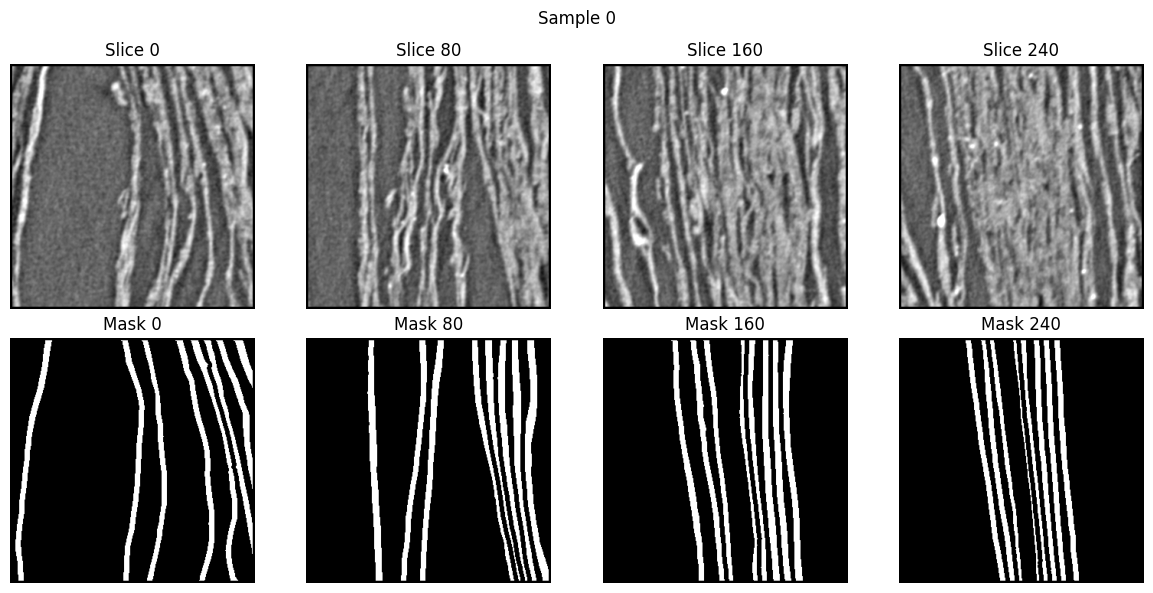

In [33]:
plot_sample(
    x, y, sample_idx=0, max_slices=4
)

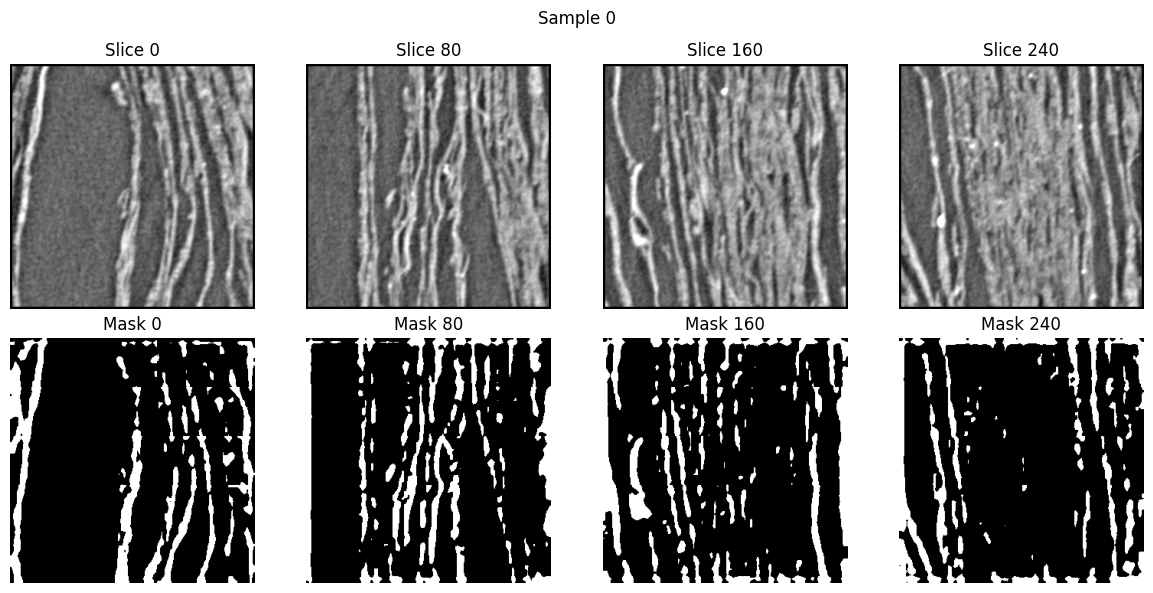

In [38]:
plot_sample(
    x, segment, sample_idx=0, max_slices=4
)